In [ ]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))) + "/src")

from dataset import (
    DatasetGenerator,
    DatasetConfig,
    save_dataset_with_reductions,
    TrialType,
)

In [8]:
SEED = 42

config = DatasetConfig(
    # Network structure
    # 100 neurons exceeds median real session from dataset we were given
    network_size=100,
    j0=-2.0,
    j1=4.0,
    # Ring Simulation
    dt=0.01,
    tau=100.0,
    sigma=0.1,
    rate_scale=100.0,
    # Binning
    bin_factor=50,
    smoothing_window=3,
    # Trial structure — 1000 bins/trial enables broad time-axis truncation experiments
    # (compare: 1 real session ≈ 127k bins at 20ms; 140 trials × 1000 bins = 140k bins)
    steps_per_trial=50000,
    cue_duration=500,
    cue_amplitude=2.0,
    # Trial counts
    n_noise_trials=20,
    n_single_cue_trials=100,
    n_perturbation_trials=20,
    seed=SEED,
)

print(f"Trials:          {config.total_trials}  ({config.n_noise_trials} noise + {config.n_single_cue_trials} cue + {config.n_perturbation_trials} perturbation)")
print(f"Steps per trial: {config.steps_per_trial:,}")
print(f"Bins per trial:  {config.bins_per_trial}")
print(f"Total bins:      {config.total_trials * config.bins_per_trial:,}  (one real session ≈ 127,000)")
print(f"dt_bin:          {config.dt_bin:.3f}")

Trials:          140  (20 noise + 100 cue + 20 perturbation)
Steps per trial: 50,000
Bins per trial:  1000
Total bins:      140,000  (one real session ≈ 127,000)
dt_bin:          0.500


In [9]:
generator = DatasetGenerator(config)

print(f"Generating {config.total_trials} trials × {config.steps_per_trial:,} steps each...")
print("(This takes ~15 min for the production config — grab a coffee)")

dataset = generator.generate()

print(f"\nDone. Stacked arrays:")
print(f"  Y_rates : {dataset.Y_rates.shape}  (trials, bins, neurons)")
print(f"  Y_theta : {dataset.Y_theta.shape}  (trials, bins)")
print(f"  X_cue   : {dataset.X_cue.shape}   (trials, bins, neurons)")
print(f"  Train idx: {len(dataset.train_idx)}  |  Test idx: {len(dataset.test_idx)}")

Generating 140 trials × 50,000 steps each...
(This takes ~15 min for the production config — grab a coffee)

Done. Stacked arrays:
  Y_rates : (140, 1000, 100)  (trials, bins, neurons)
  Y_theta : (140, 1000)  (trials, bins)
  X_cue   : (140, 1000, 100)   (trials, bins, neurons)
  Train idx: 112  |  Test idx: 28


In [11]:
# Sanity check shapes on the first trial
trial0 = dataset.trials[0]

theta_str = f"{trial0.config.theta_target:.3f} rad" if trial0.config.theta_target is not None else "None (noise trial)"
print(f"Trial type   : {trial0.trial_type.value}")
print(f"Theta target : {theta_str}")
print()
print("===== INTEGRATION-RESOLUTION SHAPES =====")
print(f"  spikes_int  : {trial0.spikes_int.shape}   (steps, neurons)")
print(f"  rates_true  : {trial0.rates_true.shape}   (steps, neurons)")
print(f"  theta_hat   : {trial0.theta_hat.shape}   (steps,)")
print(f"  confidence  : {trial0.confidence.shape}   (steps,)")
print(f"  cue_schedule: {trial0.cue_schedule.shape}   (steps, neurons)")
print()
print("===== BIN-RESOLUTION SHAPES =====")
print(f"  spikes_bin  : {trial0.spikes_bin.shape}   (bins, neurons)")
print(f"  rates_smooth: {trial0.rates_smooth.shape}   (bins, neurons)")
print(f"  theta_hat_bin: {trial0.theta_hat_bin.shape}   (bins,)")
print()
print("===== BASIC STATS =====")
print(f"  spikes mean : {trial0.spikes_int.mean():.4f}")
print(f"  spikes max  : {trial0.spikes_int.max()}")
print(f"  rates mean  : {trial0.rates_true.mean():.4f}")
print(f"  rates max   : {trial0.rates_true.max():.4f}")
print(f"  theta range : [{trial0.theta_hat.min():.3f}, {trial0.theta_hat.max():.3f}]")

Trial type   : noise_only
Theta target : None (noise trial)

===== INTEGRATION-RESOLUTION SHAPES =====
  spikes_int  : (50000, 100)   (steps, neurons)
  rates_true  : (50000, 100)   (steps, neurons)
  theta_hat   : (50000,)   (steps,)
  confidence  : (50000,)   (steps,)
  cue_schedule: (50000, 100)   (steps, neurons)

===== BIN-RESOLUTION SHAPES =====
  spikes_bin  : (1000, 100)   (bins, neurons)
  rates_smooth: (1000, 100)   (bins, neurons)
  theta_hat_bin: (1000,)   (bins,)

===== BASIC STATS =====
  spikes mean : 0.0193
  spikes max  : 3
  rates mean  : 0.0193
  rates max   : 0.0272
  theta range : [0.454, 2.398]


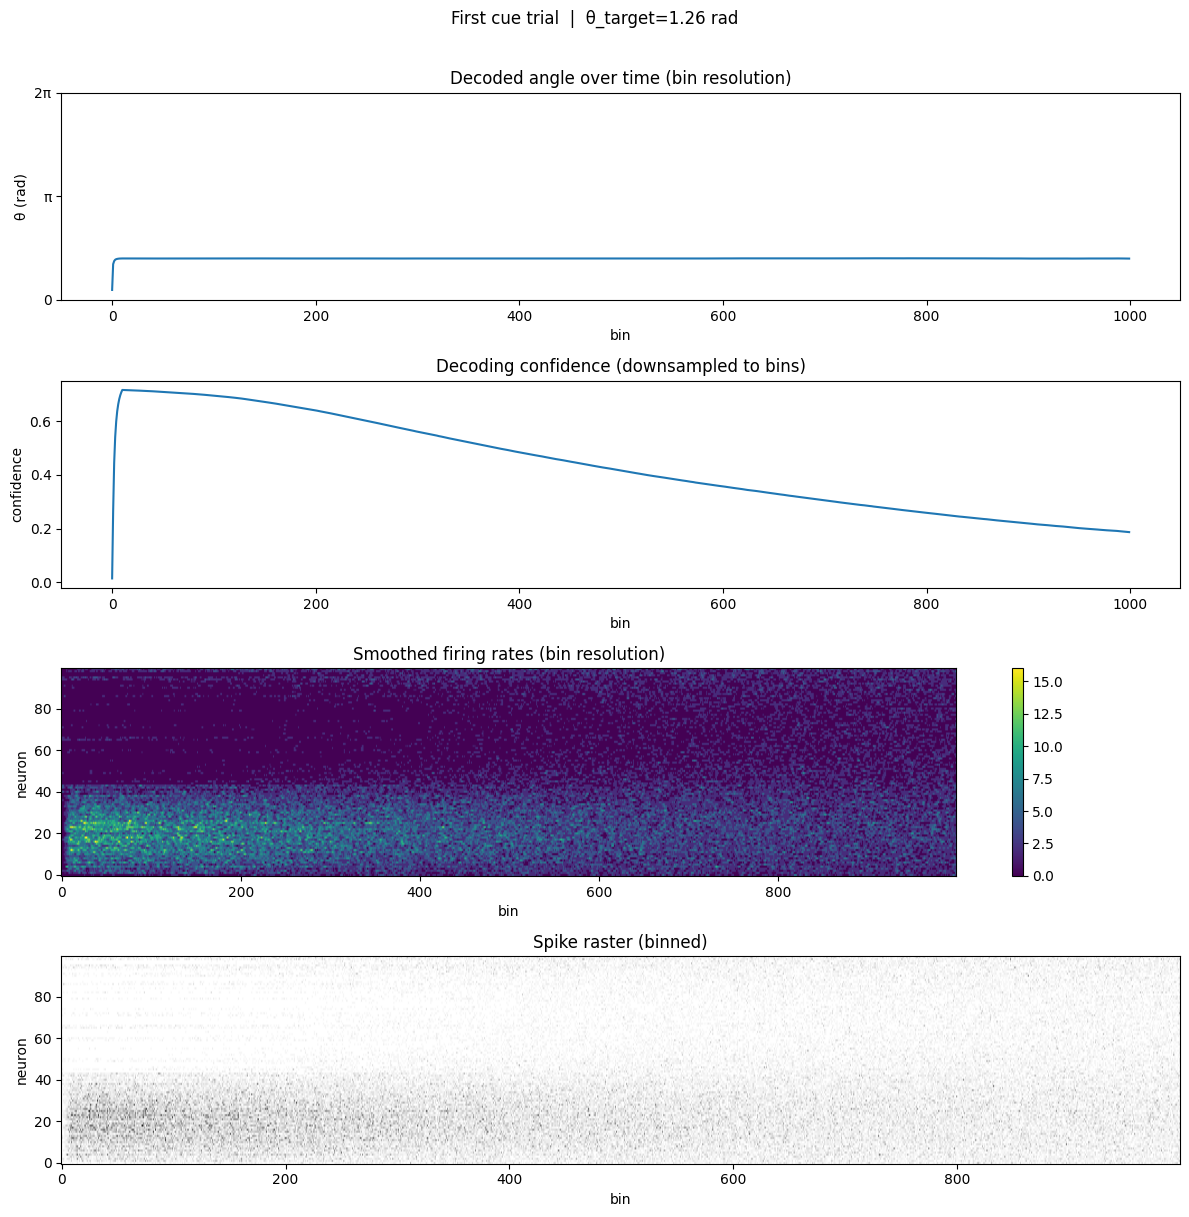

In [12]:
# Pick first single-cue trial so the angle plot is meaningful
from dataset.trial_types import TrialType as TT
cue_trial = next(t for t in dataset.trials if t.trial_type == TT.SINGLE_CUE)

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Decoded angle (bin resolution)
axes[0].plot(cue_trial.theta_hat_bin)
axes[0].set_title("Decoded angle over time (bin resolution)")
axes[0].set_xlabel("bin")
axes[0].set_ylabel("θ (rad)")
axes[0].set_yticks([0, np.pi, 2 * np.pi])
axes[0].set_yticklabels(["0", "π", "2π"])

# Decoding confidence
axes[1].plot(cue_trial.confidence[:: config.bin_factor])
axes[1].set_title("Decoding confidence (downsampled to bins)")
axes[1].set_xlabel("bin")
axes[1].set_ylabel("confidence")

# Smoothed rate heatmap (bin resolution)
im = axes[2].imshow(cue_trial.rates_smooth.T, aspect="auto", origin="lower")
axes[2].set_title("Smoothed firing rates (bin resolution)")
axes[2].set_xlabel("bin")
axes[2].set_ylabel("neuron")
plt.colorbar(im, ax=axes[2])

# Spike raster (bin resolution)
axes[3].imshow(cue_trial.spikes_bin.T, aspect="auto", origin="lower", cmap="Greys")
axes[3].set_title("Spike raster (binned)")
axes[3].set_xlabel("bin")
axes[3].set_ylabel("neuron")

plt.suptitle(f"First cue trial  |  θ_target={cue_trial.config.theta_target:.2f} rad", y=1.01)
plt.tight_layout()
plt.show()

In [13]:
import os
os.makedirs("../data", exist_ok=True)

save_dataset_with_reductions(
    dataset,
    path="../data/shared_ring_dataset.npz",
    observation_fractions=[1.0, 0.5, 0.25, 0.1],
    seed=SEED,
)

Saved dataset with reductions to ../data/shared_ring_dataset.npz
  Trials: 140
  Shape: Y_rates=(140, 1000, 100)
  Observation levels: ['100%', '50%', '25%', '10%']
  Train/test: 112/28


In [14]:
# Load check
data = np.load("../data/shared_ring_dataset.npz", allow_pickle=True)

print("Keys:", sorted(data.files))
print()
print("Core arrays:")
print(f"  Y_rates          : {data['Y_rates'].shape}   (trials, bins, neurons)")
print(f"  Y_theta          : {data['Y_theta'].shape}   (trials, bins)")
print(f"  X_cue            : {data['X_cue'].shape}   (trials, bins, neurons)")
print()
print("Observation levels:")
for key in sorted(k for k in data.files if k.startswith("X_rates_obs_")):
    print(f"  {key}: {data[key].shape}")
print()
print("Splits:")
print(f"  train_idx: {data['train_idx'].shape}  → {len(data['train_idx'])} trials")
print(f"  test_idx : {data['test_idx'].shape}   → {len(data['test_idx'])} trials")

Keys: ['X_cue', 'X_rates_obs_10', 'X_rates_obs_100', 'X_rates_obs_25', 'X_rates_obs_50', 'Y_rates', 'Y_theta', 'config_json', 'obs_idx_10', 'obs_idx_100', 'obs_idx_25', 'obs_idx_50', 'test_idx', 'theta_targets', 'train_idx', 'trial_types']

Core arrays:
  Y_rates          : (140, 1000, 100)   (trials, bins, neurons)
  Y_theta          : (140, 1000)   (trials, bins)
  X_cue            : (140, 1000, 100)   (trials, bins, neurons)

Observation levels:
  X_rates_obs_10: (140, 1000, 10)
  X_rates_obs_100: (140, 1000, 100)
  X_rates_obs_25: (140, 1000, 25)
  X_rates_obs_50: (140, 1000, 50)

Splits:
  train_idx: (112,)  → 112 trials
  test_idx : (28,)   → 28 trials
